<a href="https://colab.research.google.com/github/hadriman11/ACE6313-Food-Waste-SDG12/blob/main/notebooks/Part_B_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part B — Machine Learning Models
## ACE6313 Machine Learning — Food Waste (SDG 12)

**Author:** Student 2 (Machine Learning Models)

Run Part A first to generate `clean_food_waste.csv`. This notebook trains 6 algorithms,
tunes hyperparameters, and compares performance.


## 1. Imports & Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/clean_food_waste.csv")
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (214, 9)


,combined figures (kg/capita/year),Household estimate (kg/capita/year),Retail estimate (kg/capita/year),Food service estimate (kg/capita/year),household_ratio,retail_ratio,foodservice_ratio,Region_encoded,Confidence_encoded
0,-0.035936,-0.125577,0.153480,0.094995,-0.188037,0.270371,0.073524,12,0
1,0.009301,-0.070845,0.153480,0.094995,-0.141933,0.235596,0.036132,13,0
2,0.371193,0.367011,0.153480,0.094995,0.202311,-0.024053,-0.243065,7,0
3,-0.171645,-0.016113,-0.367865,-0.213020,0.350747,-0.470177,-0.158126,13,1
4,0.778321,0.859598,0.153480,0.094995,0.543865,-0.281674,-0.520080,14,0


## 2. Train/Test Split

In [2]:
X = df.drop(columns=["Confidence_encoded"])
y = df["Confidence_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class distribution in y:")
print(y.value_counts().sort_index())

Train: (171, 8)  Test: (43, 8)
Class distribution in y:
Confidence_encoded
0    130
1     61
2     13
3     10
Name: count, dtype: int64


## 3. Train 6 Models

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "SVM":                 SVC(),
    "kNN":                 KNeighborsClassifier(),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

baseline = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    baseline[name] = {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1":        f1_score(y_test, pred, average="weighted", zero_division=0),
    }

baseline_df = pd.DataFrame(baseline).T.round(3)
print("Baseline performance (before tuning):")
baseline_df

Baseline performance (before tuning):


,Accuracy,Precision,Recall,F1
Logistic Regression,0.860,0.781,0.860,0.818
Decision Tree,0.977,0.984,0.977,0.977
Random Forest,0.907,0.863,0.907,0.884
SVM,0.605,0.383,0.605,0.469
kNN,0.791,0.700,0.791,0.736
Gradient Boosting,0.953,0.953,0.953,0.953


## 4. Hyperparameter Tuning
Tune all models with GridSearchCV to show improvement.

In [4]:
# --- Tune Random Forest ---
rf_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}
rf_search = GridSearchCV(RandomForestClassifier(random_state=42),
                         rf_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
rf_search.fit(X_train, y_train)
print("RF best params:", rf_search.best_params_)
print("RF best CV F1:", round(rf_search.best_score_, 3))

RF best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
RF best CV F1: 0.902


In [5]:
# --- Tune SVM ---
svm_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}
svm_search = GridSearchCV(SVC(), svm_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
svm_search.fit(X_train, y_train)
print("SVM best params:", svm_search.best_params_)
print("SVM best CV F1:", round(svm_search.best_score_, 3))

SVM best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
SVM best CV F1: 0.898


In [6]:
# --- Tune kNN ---
knn_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=5,
                          scoring="f1_weighted", n_jobs=-1)
knn_search.fit(X_train, y_train)
print("kNN best params:", knn_search.best_params_)
print("kNN best CV F1:", round(knn_search.best_score_, 3))

kNN best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
kNN best CV F1: 0.844


In [15]:
# --- Tune Logistic Regression ---
lr_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
}
lr_search = GridSearchCV(LogisticRegression(max_iter=1000),
                         lr_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
lr_search.fit(X_train, y_train)
print("LR best params:", lr_search.best_params_)
print("LR best CV F1:", round(lr_search.best_score_, 3))

LR best params: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
LR best CV F1: 0.881


In [16]:
# --- Tune Decision Tree ---
dt_grid = {
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                         dt_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
dt_search.fit(X_train, y_train)
print("DT best params:", dt_search.best_params_)
print("DT best CV F1:", round(dt_search.best_score_, 3))

DT best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
DT best CV F1: 0.919


In [17]:
# --- Tune Gradient Boosting ---
gb_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
}
gb_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                         gb_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
gb_search.fit(X_train, y_train)
print("GB best params:", gb_search.best_params_)
print("GB best CV F1:", round(gb_search.best_score_, 3))

GB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
GB best CV F1: 0.93


## 5. Evaluate Tuned Models

In [10]:
tuned_models = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "SVM (tuned)":           svm_search.best_estimator_,
    "kNN (tuned)":           knn_search.best_estimator_,
    "Logistic Regression (tuned)": lr_search.best_estimator_,
    "Decision Tree (tuned)":       dt_search.best_estimator_,
    "Gradient Boosting (tuned)":   gb_search.best_estimator_,
}

tuned = {}
for name, model in tuned_models.items():
    pred = model.predict(X_test)
    tuned[name] = {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1":        f1_score(y_test, pred, average="weighted", zero_division=0),
    }

tuned_df = pd.DataFrame(tuned).T.round(3)
print("Tuned performance:")
tuned_df

Tuned performance:


,Accuracy,Precision,Recall,F1
Random Forest (tuned),0.884,0.841,0.884,0.861
SVM (tuned),0.884,0.834,0.884,0.857
kNN (tuned),0.860,0.802,0.860,0.829
Logistic Regression (tuned),0.884,0.834,0.884,0.857
Decision Tree (tuned),0.930,0.902,0.930,0.910
Gradient Boosting (tuned),0.953,0.953,0.953,0.953


In [11]:
# Detailed report for the best model
best_name = tuned_df["F1"].idxmax()
best_model = tuned_models[best_name]
pred = best_model.predict(X_test)
print(f"Best model: {best_name}\n")
print(classification_report(y_test, pred, zero_division=0))

Best model: Gradient Boosting (tuned)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        12
           2       0.67      0.67      0.67         3
           3       0.50      0.50      0.50         2

    accuracy                           0.95        43
   macro avg       0.79      0.79      0.79        43
weighted avg       0.95      0.95      0.95        43



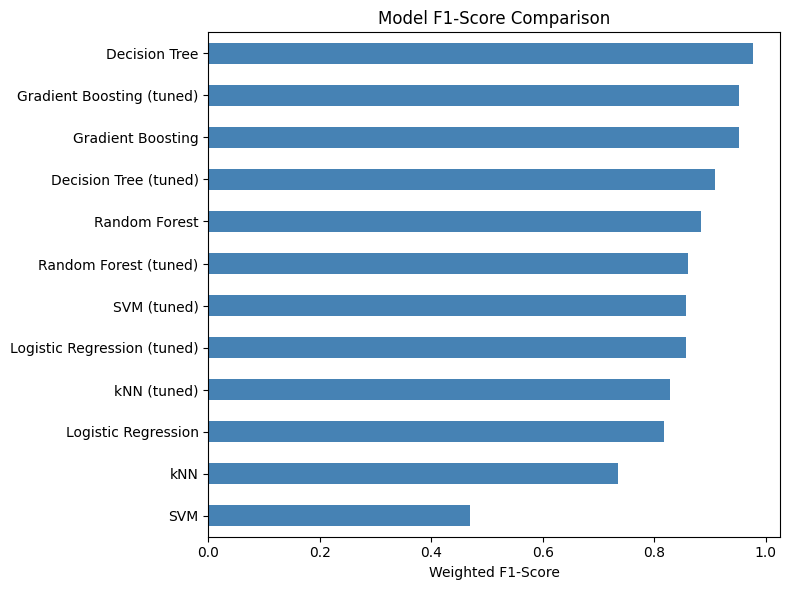

In [13]:
# Bar chart of F1-scores
all_results["F1"].sort_values().plot(kind="barh", figsize=(8,6), color="steelblue")
plt.title("Model F1-Score Comparison")
plt.xlabel("Weighted F1-Score")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/model_comparison.png", dpi=150)
plt.show()

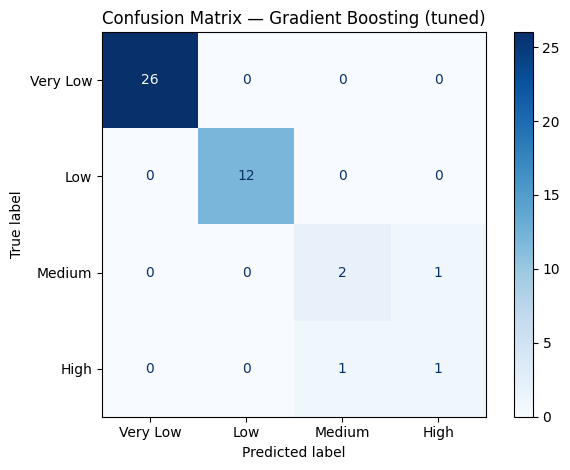

In [14]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Very Low","Low","Medium","High"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/confusion_matrix.png", dpi=150)
plt.show()